In [49]:
# Import libraries
import pandas as pd
import numpy as np

In [50]:
# Load train, test, valid data
try:
    df_train = pd.read_csv("../data/raw/train.tsv", sep='\t')
    df_test = pd.read_csv("../data/raw/test.tsv", sep='\t')
    df_valid = pd.read_csv("../data/raw/validation.tsv", sep='\t')
except FileNotFoundError:
    print("File not found! Check path.")

In [51]:
# Concatenate all data for uniform cleaning
df_all = pd.concat([df_train, df_test, df_valid], ignore_index=True)

# Drop unnecessary columns
df_all = df_all.drop(columns=['subject', 'date', 'Unnamed: 0'], errors='ignore')
print("All data shape:", df_all.shape)

All data shape: (44267, 3)


In [52]:
# Check number of duplicate texts or titles in all_data
print("Duplicate titles in all data:", df_all.duplicated(subset=['title']).sum())
print("Duplicate texts in all data:", df_all.duplicated(subset=['text']).sum())
print("Duplicate both text and title in all data:", df_all.duplicated(subset=['title', 'text']).sum())

Duplicate titles in all data: 5986
Duplicate texts in all data: 5629
Duplicate both text and title in all data: 5612


In [53]:
# Xoá trùng hoàn toàn (title + text)
before = len(df_all)
df_all = df_all.drop_duplicates(subset=['title'], keep='first')
df_all = df_all.drop_duplicates(subset=['text'], keep='first')
after = len(df_all)
print(f"Removed {before - after} exact duplicates")

Removed 6003 exact duplicates


In [54]:
# Check label distribution
print("Label distribution in all data:\n", df_all['label'].value_counts(normalize=True))

Label distribution in all data:
 label
1    0.544088
0    0.455912
Name: proportion, dtype: float64


In [55]:
df_all[0:1]['text'].values[0]

'Former CIA director John Brennan on Friday criticized as “disgraceful” President Donald Trump’s efforts to play down U.S. intelligence agencies’ assessment that Russia meddled in the 2016 U.S. election. Trump’s administration has been dogged by investigations into allegations of Russian interference in last year’s U.S. presidential election and possible ties with his campaign team. Speaking one day before his first meeting with Russian President Vladimir Putin in Hamburg earlier this month, Trump said he suspected Russian interference in the election but that no one knows for sure. “These types of comments are just disgraceful ... and the person who said them should be ashamed of himself,” said Brennan, CIA chief under former President Barack Obama, at the Aspen Security Forum. Special Counsel Robert Mueller and several U.S. congressional committees are investigating whether Russia interfered in the election and colluded with Trump’s campaign to try to swing the race in his favor over

In [56]:
import re
def normalize_abbreviations(text):
    text = re.sub(r'\bu\.s\.', 'united_states', text, flags=re.IGNORECASE)
    text = re.sub(r'\bu\.n\.', 'united_nations', text, flags=re.IGNORECASE)
    text = re.sub(r'\bu\.k\.', 'united_kingdom', text, flags=re.IGNORECASE)
    text = re.sub(r'\be\.u\.', 'european_union', text, flags=re.IGNORECASE)
    return text

In [57]:
import contractions
def expand_contractions(text):
    """
    Mở rộng các từ viết tắt tiếng Anh (contractions)
    """
    return contractions.fix(text)

In [ ]:
# # Remove stopwords using nltk
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer

# stop_words = set(stopwords.words('english')) - {'no', 'not', 'nor'}
# lemmatizer = WordNetLemmatizer()

# def preprocess_text(text, remove_stopwords=True, use_lemmatization=True):
#     """
#     Hàm tiền xử lý văn bản:
#       - Xóa HTML, URL, ký tự đặc biệt
#       - Chuẩn hóa viết tắt & từ rút gọn
#       - Loại bỏ stopwords (tùy chọn)
#       - Lemmatization (tùy chọn)
#     """

#     # 1️⃣ Chuyển về chữ thường
#     text = text.lower()

#     # 2️⃣ Xóa HTML tags và URL
#     text = re.sub(r'<.*?>', ' ', text)
#     text = re.sub(r'http\S+|www\S+', ' ', text)

#     # 4️⃣ Chuẩn hóa viết tắt (US, U.N., v.v.)
#     text = normalize_abbreviations(text)

#     # 3️⃣ Mở rộng từ rút gọn
#     text = expand_contractions(text)

#     # 5️⃣ Xóa ký tự đặc biệt, giữ lại chữ và số
#     text = re.sub(r'[^a-z0-9\s]', ' ', text)

#     # 6️⃣ Xóa khoảng trắng thừa
#     text = re.sub(r'\s+', ' ', text).strip()

#     # 7️⃣ Tokenization
#     tokens = nltk.word_tokenize(text)

#     # 8️⃣ Loại bỏ stopwords (nếu cần)
#     if remove_stopwords:
#         tokens = [w for w in tokens if w not in stop_words]
    
#     # 9️⃣ Lemmatization (nếu cần)
#     if use_lemmatization:
#         tokens = [lemmatizer.lemmatize(w) for w in tokens]

#     return " ".join(tokens)
# df_all['text'] = df_all['text'].apply(preprocess_text, remove_stopwords=True, use_lemmatization=True)
# df_all['title'] = df_all['title'].apply(preprocess_text, remove_stopwords=True, use_lemmatization=True)

In [59]:
import pandas as pd
import numpy as np
import re
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- Khởi tạo các công cụ cần thiết ---
stop_words = set(stopwords.words('english')) - {'no', 'not', 'nor'}
lemmatizer = WordNetLemmatizer()

# --- Hàm 1: Tiền xử lý đầy đủ cho TF-IDF (trả về chuỗi) ---
def preprocess_full_for_tfidf(text):
    text = text.lower()
    text = re.sub(r'<.*?>|http\S+|www\S+', ' ', text)
    text = normalize_abbreviations(text)
    text = contractions.fix(text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# --- Hàm 2: Tiền xử lý cho Word2Vec (trả về list of tokens) ---
def preprocess_for_word2vec(text):
    text = text.lower()
    text = re.sub(r'<.*?>|http\S+|www\S+', ' ', text)
    text = normalize_abbreviations(text)
    text = contractions.fix(text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = nltk.word_tokenize(text)
    # Có thể giữ lại stopwords cho Word2Vec để có ngữ cảnh tốt hơn, tùy vào bài toán
    # tokens = [w for w in tokens if w not in stop_words] 
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens

# --- Hàm 3: Tiền xử lý nhẹ cho BERT (trả về chuỗi) ---
def preprocess_light_for_bert(text):
    text = text.lower() # Giả sử dùng BERT uncased
    text = re.sub(r'<.*?>|http\S+|www\S+', ' ', text)
    text = contractions.fix(text) # Mở rộng từ rút gọn là một bước tốt
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [60]:
# Gộp title và text gốc trước
df_all['combined_raw'] = df_all['title'] + ' ' + df_all['text']

# Áp dụng các hàm tiền xử lý
print("Starting preprocessing for TF-IDF...")
df_all['text_tfidf'] = df_all['combined_raw'].apply(preprocess_full_for_tfidf)

print("Starting preprocessing for Word2Vec...")
df_all['text_word2vec'] = df_all['combined_raw'].apply(preprocess_for_word2vec)

print("Starting preprocessing for BERT...")
df_all['text_bert'] = df_all['combined_raw'].apply(preprocess_light_for_bert)

# Xóa các hàng có văn bản rỗng sau khi xử lý
df_all = df_all[df_all['text_tfidf'].str.strip() != '']
df_all = df_all[df_all['text_bert'].str.strip() != '']

print("Preprocessing finished.")
print(df_all[['text_tfidf', 'text_word2vec', 'text_bert', 'label']].head())

Starting preprocessing for TF-IDF...
Starting preprocessing for Word2Vec...
Starting preprocessing for BERT...
Preprocessing finished.
                                          text_tfidf  \
0  ex cia head say trump remark russia interferen...   
1  not believe punishment hispanic store owner sw...   
2  federal reserve governor powell policy view wo...   
3  scoundrel hillary supporter start trumpleaks c...   
4  nancy pelosi arrogantly dismisses question cro...   

                                       text_word2vec  \
0  [ex, cia, head, say, trump, remark, on, russia...   
1  [you, will, not, believe, his, punishment, his...   
2  [federal, reserve, governor, powell, s, policy...   
3  [scoundrel, hillary, supporter, start, trumple...   
4  [nancy, pelosi, arrogantly, dismisses, questio...   

                                           text_bert  label  
0  ex-cia head says trump remarks on russia inter...      1  
1  you will not believe his punishment! hispanic ...      0  
2  fe

In [61]:
# 1. Lưu dữ liệu cho TF-IDF
df_tfidf = df_all[['text_tfidf', 'label']].copy()
df_tfidf.to_csv('../data/processed/data_for_tfidf.csv', index=False)
print("Saved data for TF-IDF to data_for_tfidf.csv")


# 2. Lưu dữ liệu cho Word2Vec
# Dùng định dạng pickle hoặc json sẽ tốt hơn CSV khi lưu danh sách
df_word2vec = df_all[['text_word2vec', 'label']].copy()
df_word2vec.to_pickle('../data/processed/data_for_word2vec.pkl')
print("Saved data for Word2Vec to data_for_word2vec.pkl")


# 3. Lưu dữ liệu cho BERT
df_bert = df_all[['text_bert', 'label']].copy()
df_bert.to_csv('../data/processed/data_for_bert.csv', index=False)
print("Saved data for BERT to data_for_bert.csv")

Saved data for TF-IDF to data_for_tfidf.csv
Saved data for Word2Vec to data_for_word2vec.pkl
Saved data for BERT to data_for_bert.csv


# TEST

In [62]:
# Gộp title và text
df_all['combined'] = df_all['title'] + ' ' + df_all['text']

# Shuffle lại để tránh thứ tự cũ
all_data = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

# Chia lại train/val/test
train_size = 0.8
val_size = 0.1

train_end = int(train_size * len(all_data))
val_end = int((train_size + val_size) * len(all_data))

df_train = all_data[:train_end]
df_valid = all_data[train_end:val_end]
df_test = all_data[val_end:]

print(len(df_train), len(df_valid), len(df_test))

30607 3826 3826


In [63]:
# check percentage of labels in train, test, validation data
print("Label distribution in train data:\n", df_train['label'].value_counts(normalize=True))
print("Label distribution in test data:\n", df_test['label'].value_counts(normalize=True))
print("Label distribution in validation data:\n", df_valid['label'].value_counts(normalize=True))

Label distribution in train data:
 label
1    0.54187
0    0.45813
Name: proportion, dtype: float64
Label distribution in test data:
 label
1    0.564297
0    0.435703
Name: proportion, dtype: float64
Label distribution in validation data:
 label
1    0.542342
0    0.457658
Name: proportion, dtype: float64


In [64]:
# Check info distribution of text length
df_all['text_length'] = df_all['text'].apply(lambda x: len(x.split()))
print(df_all['text_length'].describe())

count    38259.00000
mean       400.42505
std        312.87433
min          1.00000
25%        215.00000
50%        367.00000
75%        508.00000
max       8135.00000
Name: text_length, dtype: float64


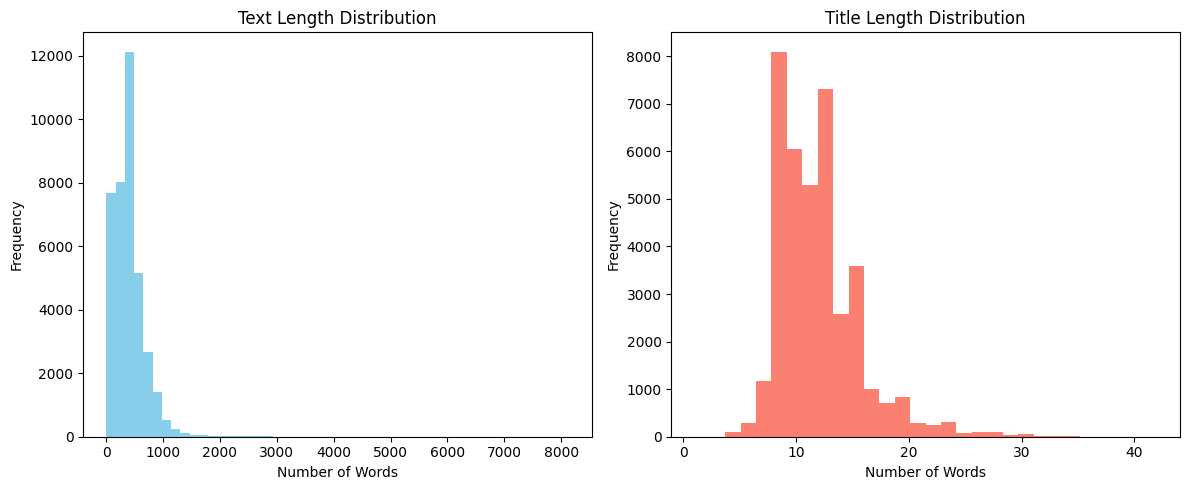

In [65]:
# plot length of text and title
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_all['text'].apply(lambda x: len(x.split())), bins=50, color='skyblue')
plt.title('Text Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(df_all['title'].apply(lambda x: len(x.split())), bins=30, color='salmon')
plt.title('Title Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [66]:
# check blank text or title
print("Blank texts:", (df_all['text'].str.strip() == '').sum())
print("Blank titles:", (df_all['title'].str.strip() == '').sum())
# Remove rows with blank text or title
df_all = df_all[(df_all['text'].str.strip() != '') & (df_all['title'].str.strip() != '')]
print("Data shape after removing blank text/title:", df_all.shape)


Blank texts: 0
Blank titles: 0
Data shape after removing blank text/title: (38259, 9)


In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,      # số từ tối đa
    ngram_range=(1,2),      # dùng cả unigram và bigram
    sublinear_tf=True       # giảm trọng số TF cho từ xuất hiện nhiều
)
tfidf.fit(df_train['combined'])
X_train_tfidf = tfidf.transform(df_train['combined'])
X_valid_tfidf = tfidf.transform(df_valid['combined'])
X_test_tfidf  = tfidf.transform(df_test['combined'])
print(X_train_tfidf.shape, X_valid_tfidf.shape, X_test_tfidf.shape)

(30607, 5000) (3826, 5000) (3826, 5000)


In [68]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, df_train['label'])

y_pred = model.predict(X_valid_tfidf)
from sklearn.metrics import classification_report, accuracy_score
print("Validation Accuracy:", accuracy_score(df_valid['label'], y_pred))
print(classification_report(df_valid['label'], y_pred))

Validation Accuracy: 0.9898065865133299
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1751
           1       0.98      1.00      0.99      2075

    accuracy                           0.99      3826
   macro avg       0.99      0.99      0.99      3826
weighted avg       0.99      0.99      0.99      3826



In [69]:
y_pred = model.predict(X_test_tfidf)
from sklearn.metrics import classification_report, accuracy_score
print("Validation Accuracy:", accuracy_score(df_test['label'], y_pred))
print(classification_report(df_test['label'], y_pred))

Validation Accuracy: 0.989022477783586
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1667
           1       0.99      0.99      0.99      2159

    accuracy                           0.99      3826
   macro avg       0.99      0.99      0.99      3826
weighted avg       0.99      0.99      0.99      3826

